In [2]:
# IMPORT & LOAD DATA
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load RFM data
df = pd.read_csv("D:/customer-segmentation-unsupervised/data/processed/rfm_data.csv")

print("Data Loaded ")
df.head()

Data Loaded 


,user_id,Recency,Frequency,Monetary,Views,Carts,Purchase_Ratio,Avg_Spend
0,356520186,0,1,33.45,5.0,0.0,0.166667,16.725000
1,397023870,0,1,244.28,3.0,0.0,0.250000,122.140000
2,486999716,0,1,242.72,3.0,0.0,0.250000,121.360000
3,509881222,0,1,200.52,55.0,0.0,0.017857,100.260000
4,512364896,0,5,708.01,16.0,3.0,0.294118,118.001667


In [3]:
# PREPARE DATA FOR CLUSTERING
# Remove user_id if present
if "user_id" in df.columns:
    df = df.drop(columns=["user_id"])

# Handle missing values
df = df.fillna(0)

# Scaling (VERY IMPORTANT)
scaler = StandardScaler()
X = scaler.fit_transform(df)

print("Data Scaled Successfully ")

Data Scaled Successfully 


In [4]:
# K-MEANS CLUSTERING
from sklearn.cluster import KMeans

# Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

# Add labels
df["KMeans_Cluster"] = kmeans_labels

print("KMeans Done ")

KMeans Done 


In [6]:
# DBSCAN CLUSTERING
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

df["DBSCAN_Cluster"] = dbscan_labels

print("DBSCAN Done ")


DBSCAN Done 


In [7]:
# GAUSSIAN MIXTURE MODEL (GMM)
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(X)

df["GMM_Cluster"] = gmm_labels

print("GMM Done ")

GMM Done 


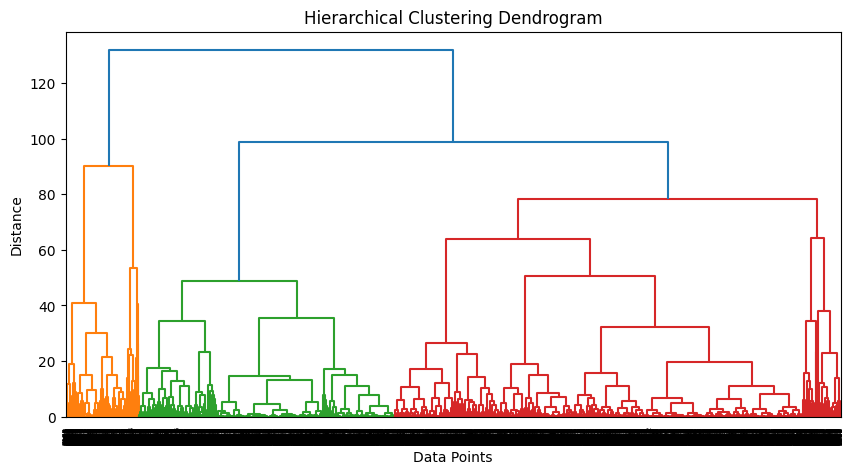

In [8]:
# HIERARCHICAL CLUSTERING
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

linked = linkage(X, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [9]:
# SAVE RESULTS
df.to_csv("D:/customer-segmentation-unsupervised/results/cluster_plots/clustering_results.csv", index=False)

print("Clustering Results Saved ")

Clustering Results Saved 


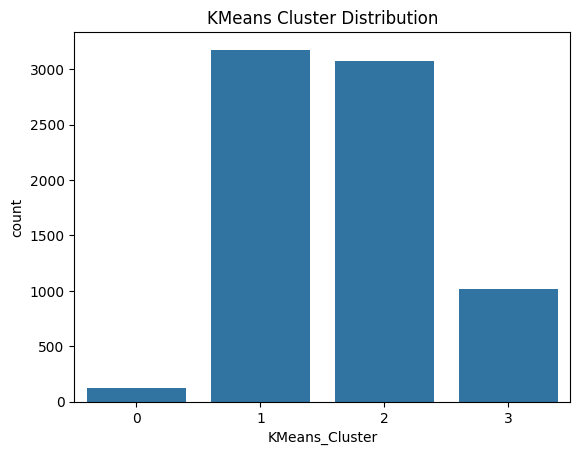

In [13]:
# KMEANS CLUSTER COUNT PLOT
import seaborn as sns

plt.figure()
sns.countplot(x="KMeans_Cluster", data=df)
plt.title("KMeans Cluster Distribution")

plt.savefig("D:/customer-segmentation-unsupervised/results/cluster_plots/kmeans_distribution.png")

plt.show()

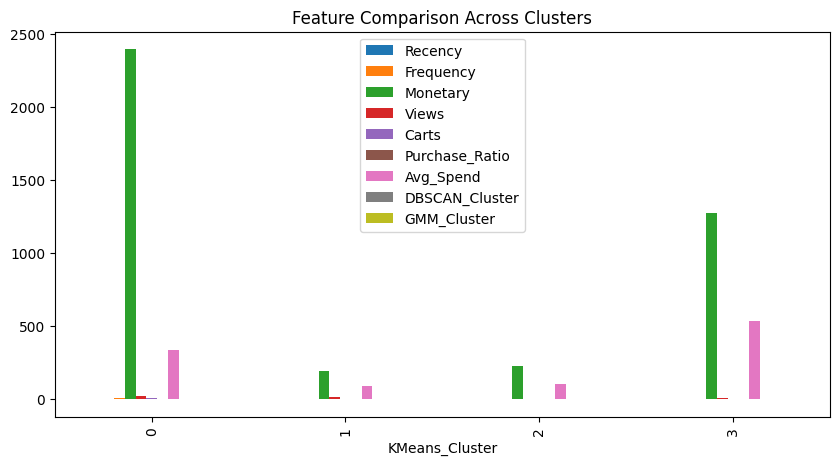

In [14]:
# FEATURE COMPARISON BY CLUSTER
cluster_summary = df.groupby("KMeans_Cluster").mean()

cluster_summary.plot(kind="bar", figsize=(10,5))
plt.title("Feature Comparison Across Clusters")

plt.savefig("D:/customer-segmentation-unsupervised/results/cluster_plots/feature_comparison.png")

plt.show()

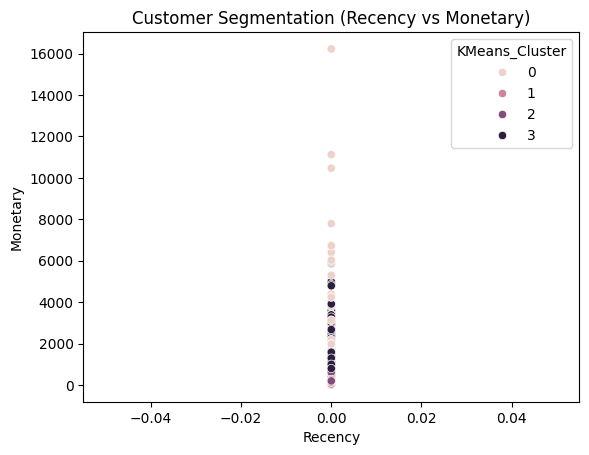

In [15]:
# SCATTER PLOT
plt.figure()
sns.scatterplot(x=df["Recency"], y=df["Monetary"], hue=df["KMeans_Cluster"])

plt.title("Customer Segmentation (Recency vs Monetary)")

plt.savefig("D:/customer-segmentation-unsupervised/results/cluster_plots/scatter_plot.png")

plt.show()

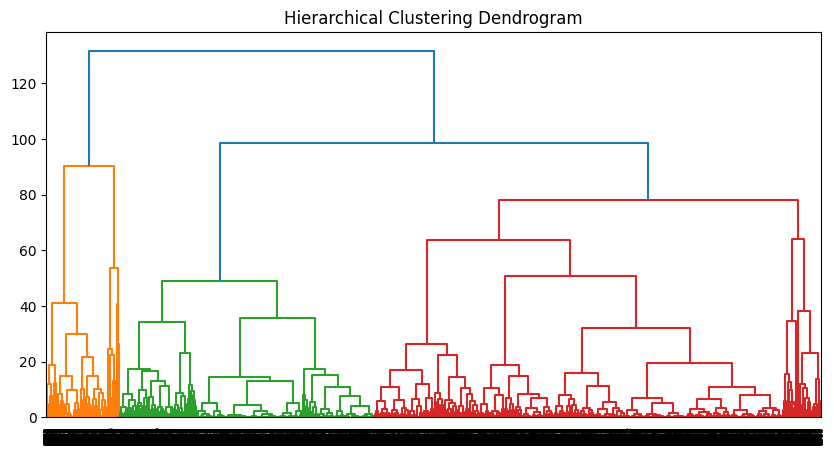

In [16]:
# DENDROGRAM
plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")

plt.savefig("D:/customer-segmentation-unsupervised/results/cluster_plots/dendrogram.png")

plt.show()